In [2]:
# %%
import numpy
import pandas
import os
import numpy
import scipy
import mod_utils as utils
import matplotlib.pyplot as plt
import os
math_vars = {
    'high_rho': 3,
    'low_rho' : 1,
    'high_visc' : 0.001, #dynamic
    'low_visc' : 0.001,#0.0005,
    'wavelength' : 1,
    'grev': 1,
    'x_L' : 1,
    'y_L' : 4,
    'delta_h': 0.05,
    'timestep': 0.0035,
    'time_end': 8,
    'maxWidthCutOff': 0.01,
    'surface_tension': 1e-05
}

model = utils.dynamic_model(math_vars)

model.set_nondim_consts(
    ref_l = 'x_L',
    ref_rho = 'high_rho',
    ref_grev = 'grev',
    ref_visc = 'low_visc',
    ref_visc_kin = lambda ref_visc, ref_rho: ref_visc/ref_rho, 
    ref_u = lambda ref_grev, ref_l: numpy.sqrt(ref_grev*ref_l),
    ref_surface_tension = lambda ref_l, ref_rho, ref_u, surface_tension: ref_rho*ref_l*numpy.pow(ref_u, 2)*surface_tension
)

#{} means it's in the mod_utils as a seperate class method, otherwise lambda
model.calculate_nondim_nums(
    atwood = {},
    reynolds = {},
    froude = {},
    #grashof = {},
    grash2 = lambda high_rho, low_rho, ref_grev, ref_l, ref_visc, ref_rho: ((high_rho - low_rho)/(high_rho + low_rho))*ref_grev*numpy.pow(ref_l, 3)/numpy.pow((ref_visc/ref_rho), 2),#Aglam^3/kin_visc^2
    #ren2 = lambda ref_grev, ref_l, ref_rho, ref_visc: (numpy.sqrt(numpy.pow(ref_l,3)*ref_grev)*ref_rho)/ref_visc
    weber = lambda ref_rho, ref_l, ref_u, ref_surface_tension: ref_rho*ref_l*(numpy.pow(ref_u, 2))/ref_surface_tension,
    eotvos = lambda high_rho, low_rho, ref_grev, ref_l, ref_surface_tension: (high_rho - low_rho)*ref_grev*numpy.pow(ref_l, 2)/ref_surface_tension
    )

name_vars = {
    'x_dat': "X (m)",
    'y_dat': "Y (m)",
    'v_x': "Velocity[i] (m/s)",
    'v_y': "Velocity[j] (m/s)",
    'rel_v_x': "Relative Velocity[i] (m/s)",
    "rel_v_y": "Relative Velocity[j] (m/s)",
    'volFrac_high': "Volume Fraction of high_rho",
    'volFrac_low': "Volume Fraction of low_rho",
    'min_mixWidth': "minMixWidthEval",
    'max_mixWidth': "maxMixWidthEval",
    'massFlux': "Report: massImbalance_highRho (kg)",
    'mean_rho': "Density (kg/m^3)"
}
# %% Error Calculations and Interpolations
##########################################################################
##########################################################################
def find_nearest(array, value):
    array = numpy.asarray(array)
    idx = (numpy.abs(array - value)).argmin()
    return idx, array[idx]
def interpolate_central_difference(y_val, timesteps, time):
    interpolated_values = []
    
    for t in time:
        # Find the nearest index and corresponding timestep
        idx_nearest, t_nearest = find_nearest(timesteps, t)

        # Check if we can apply central difference
        if idx_nearest > 0 and idx_nearest < len(timesteps) - 1:
            # Central difference interpolation
            delta_t = timesteps[idx_nearest + 1] - timesteps[idx_nearest - 1]
            f_plus = y_val[idx_nearest + 1]
            f_minus = y_val[idx_nearest - 1]
            
            # Linear interpolation using neighbors
            interp_value = f_minus + ((f_plus - f_minus) / delta_t) * (t - timesteps[idx_nearest - 1])
        
        elif idx_nearest == 0:  # Forward difference for first element
            delta_t = timesteps[1] - timesteps[0]
            f_plus = y_val[1]
            f_current = y_val[0]
            
            interp_value = f_current + ((f_plus - f_current) / delta_t) * (t - timesteps[0])
        
        else:  # Backward difference for last element
            delta_t = timesteps[-1] - timesteps[-2]
            f_minus = y_val[-2]
            f_current = y_val[-1]

            interp_value = f_minus + ((f_current - f_minus) / delta_t) * (t - timesteps[-2])

        interpolated_values.append(interp_value)
    return numpy.array(interpolated_values)
def calc_errors(dns_ar, model_ar):
    L2_err = 0
    Linf_err = []
    for idx, model_val in enumerate(model_ar):
        dns_val = dns_ar[idx]
        err = numpy.abs(dns_val - model_val)
        Linf_err.append(err)
        L2_err = L2_err + numpy.square(err)
    L2_err = numpy.sqrt(L2_err)
    return L2_err, Linf_err
####################################################################
####################################################################
####################################################################


{'atwood_num': 0.5, 'reynolds_num': np.float64(3000.0), 'froude_num': np.float64(1.0), 'grash2_num': np.float64(4500000.0), 'weber_num': np.float64(99999.99999999999), 'eotvos_num': np.float64(66666.66666666666)}


In [ ]:
# %% ###############################################################
######################## Convergence Study #########################
####################################################################
dir_list = [
    #r'/home/yy310050/Desktop/thesis/rayleigh_taylor/final_sims/convergence/Re300_At0.5_sigma1e-05_dh0.05',
    #r"/home/yy310050/Desktop/thesis/rayleigh_taylor/final_sims/convergence/Re300_At0.5_sigma1e-05_dh0.007",
    #r"/hpcwork/yy310050/thesis/rayleigh_taylor/VOF/final_sims/convergence/Re300_At0.5_sigma1e-05_dh0.0045",
    #r"/hpcwork/yy310050/thesis/rayleigh_taylor/2Fluid/test/HELP3",
    #r"/home/yy310050/Desktop/thesis/rayleigh_taylor/2Fluid/test/tuning/relaxation_060",
    #r"/home/yy310050/Desktop/thesis/rayleigh_taylor/2Fluid/test/tuning/relaxation_060_w_drag",
    # r"/hpcwork/yy310050/thesis/rayleigh_taylor/2Fluid/test/tuning/relaxation_050_lowiter",
    #r"/hpcwork/yy310050/thesis/rayleigh_taylor/2Fluid/test/tuning/relaxation_lower_drag_lowiter",
    #r"C:\Users\harsh\Desktop\pix\Re300_At0.2_sigma1e-05_dh0.0045",
    #r'C:\Users\harsh\Desktop\pix\RT_evolution\re300_at05',
    #r"C:\Users\harsh\Desktop\pix\Re1000_At0.2_sigma1e-05_dh0.0045",
    #r"C:\Users\harsh\Desktop\pix\Re1000_At0.5_sigma1e-05_dh0.0045",
    r"C:\Users\harsh\Desktop\pix\RT_evolution\Re3000_At0.2_sigma1e-05_dh0.0045",
    #r"C:\Users\harsh\Desktop\pix\RT_evolution\re3000_at05_0045"
    #r"/hpcwork/yy310050/thesis/rayleigh_taylor/2Fluid/test/tuning/more_tuning_tension",
    #r"/hpcwork/yy310050/thesis/rayleigh_taylor/2Fluid/test/tuning/more_relax_verify",
    #r"/hpcwork/yy310050/thesis/rayleigh_taylor/2Fluid/test/tuning/CHEAPER/whack",
    #r"/hpcwork/yy310050/thesis/rayleigh_taylor/2Fluid/test/tuning/CHEAPER/relax_020",
    #r"/hpcwork/yy310050/thesis/rayleigh_taylor/2Fluid/test/tuning/CHEAPER/relax_020_lowStepIter",
    #r"/hpcwork/yy310050/thesis/rayleigh_taylor/2Fluid/test/tuning/CHEAPER/lowStepIter_020",
    
    #r"/home/yy310050/Desktop/thesis/rayleigh_taylor/final_sims/convergence/Re300_At0.5_sigma1e-05_dh0.0025",
    #r"/home/yy310050/Desktop/thesis/rayleigh_taylor/final_sims/convergence/Re300_At0.5_sigma1e-05_dh0.0005"
]
name = 'isosurface_table_'
name_append = '.csv'
#if reference time is different from the reference time initially set
ref_t = lambda atwood_num: numpy.sqrt(atwood_num)
#model.load_solution_data(dir, name, name_append, name_vars, ref_t= ref_t)
#model.calculate_stuff()
names = ['Re1000_At0.5']#['Re300_At0.2', 'Re300_At0.5', 'Re1000_At0.2', 'Re1000_At0.5', 'Re3000_At0.2', 'Re3000_At0.5']
h_data = []
for idx, path in enumerate(dir_list):
    model.load_solution_data(path, name, name_append, name_vars, ref_t= ref_t)
    model.calculate_stuff()
    cur_h_data = {}
    cur_h_data['dh'] = names[idx]
    cur_h_data['timesteps'] = model.params['timesteps']
    cur_h_data.update(model.analysis_data)
    h_data.append(cur_h_data)
#----------------------------------------------------
dns_df = pandas.read_csv(r"C:\Users\harsh\Desktop\pix\RT_evolution\dns_compare_data\2D_Single-Mode_At0.2_Re3000_A0.05.csv")
#----------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scienceplots
import tol_colors
from itertools import cycle
from matplotlib.legend_handler import HandlerTuple
fig, ax = plt.subplots(figsize=(3,3), dpi=600)
with plt.style.context('science-modern', 'modern-contrast'):
    marks = cycle(['o', 's', '^', 'd', 'v', 'x'])
    ls_cycler = cycle(['-.', '-.'])
    L2_data = []
    Linf_data = []
    
    for h in h_data:
        line_bub, = ax.plot(
            h['timesteps'][h['timesteps'] < dns_df['Time'].max()], 
            h['y_bub'][h['timesteps'] < dns_df['Time'].max()], 
            label=fr"Sim: {h['dh']}", linestyle=next(ls_cycler))#, marker = 'o',markerfacecolor='none')
        ax.plot(
            h['timesteps'][h['timesteps'] < dns_df['Time'].max()], 
            h['y_spike'][h['timesteps'] < dns_df['Time'].max()], 
            color=line_bub.get_color(),
                linestyle=line_bub.get_linestyle(),
                label="_nolegend_")#, marker = 'x')
        L2_err_spike, Linf_err_spike = calc_errors(dns_df['Spike'], interpolate_central_difference(h['y_spike'], h['timesteps'], dns_df['Time']))
        L2_err_bubble, Linf_err_bubble = calc_errors(dns_df['Bubble'], interpolate_central_difference(h['y_bub'], h['timesteps'], dns_df['Time']))
        L2_data.append([L2_err_spike, L2_err_bubble])
        Linf_data.append([numpy.max(Linf_err_spike), numpy.max(Linf_err_bubble)])
    
    dns_bub, = ax.plot(dns_df['Time'], dns_df['Bubble'], 'o',
                           color='black', markerfacecolor='none',
                           label='__nolegend_')
    dns_spk,  = ax.plot(dns_df['Time'], dns_df['Spike'],  'x',
                           color=dns_bub.get_color(), markerfacecolor='none',
                           label='__nolegend_')
    ax.set_xlim(0, None)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))

    label_font = {'fontsize': 12}#, 'fontfamily': 'Arial'}
    ax.set_xlabel(r"Time, $t^{*}/\sqrt{At}$, (s)" , **label_font)
    ax.set_ylabel(r"$y^{*}$ (m)", **label_font)

    handles, labels = ax.get_legend_handles_labels()
    handles.append((dns_bub, dns_spk))
    labels.append('DNS: Re1000_At0.5')
    #ax.legend(handles, labels,
    #              handler_map={tuple: HandlerTuple(ndivide=None)},
    #              loc='lower left', frameon=True, prop={'size': 10})
    ax.grid(which='minor', linestyle='--', linewidth=0.1, alpha=0.3)  # minor grid
    ax.grid(which='major', linestyle='-',  linewidth=0.3, alpha=0.45) 
    plt.setp(ax.get_xticklabels(), fontsize=12)
    plt.setp(ax.get_yticklabels(), fontsize=12)
#ax.grid(True)
    plt.show()
#----------------------------------------------------
print("L2 errors: ")
for i, h in enumerate(h_data):
    print("dh: ", h['dh'])
    print("spike L2 error: ", L2_data[i][0])
    print("bubble L2 error: ", L2_data[i][1])
print("L_inf errors: ")
for i, h in enumerate(h_data):
    print("dh: ", h['dh'])
    print("spike L_inf error: ", Linf_data[i][0])
    print("bubble L_inf error: ", Linf_data[i][1])


In [ ]:
# %% ###############################################################
######################## Convergence Study #########################
####################################################################
dir_list = [
    #r'/home/yy310050/Desktop/thesis/rayleigh_taylor/final_sims/convergence/Re300_At0.5_sigma1e-05_dh0.05',
    #r"/home/yy310050/Desktop/thesis/rayleigh_taylor/final_sims/convergence/Re300_At0.5_sigma1e-05_dh0.007",
    #r"/hpcwork/yy310050/thesis/rayleigh_taylor/VOF/final_sims/convergence/Re300_At0.5_sigma1e-05_dh0.0045",
    #r"/hpcwork/yy310050/thesis/rayleigh_taylor/2Fluid/test/HELP3",
    #r"/home/yy310050/Desktop/thesis/rayleigh_taylor/2Fluid/test/tuning/relaxation_060",
    #r"/home/yy310050/Desktop/thesis/rayleigh_taylor/2Fluid/test/tuning/relaxation_060_w_drag",
    # r"/hpcwork/yy310050/thesis/rayleigh_taylor/2Fluid/test/tuning/relaxation_050_lowiter",
    #r"/hpcwork/yy310050/thesis/rayleigh_taylor/2Fluid/test/tuning/relaxation_lower_drag_lowiter",
    #r"C:\Users\harsh\Desktop\pix\Re300_At0.2_sigma1e-05_dh0.0045",
    #r'C:\Users\harsh\Desktop\pix\RT_evolution\re300_at05',
    #r"C:\Users\harsh\Desktop\pix\Re1000_At0.2_sigma1e-05_dh0.0045",
    #r"C:\Users\harsh\Desktop\pix\Re1000_At0.5_sigma1e-05_dh0.0045",
    r"C:\Users\harsh\Desktop\pix\RT_evolution\Re3000_At0.2_sigma1e-05_dh0.0045",
    #r"C:\Users\harsh\Desktop\pix\RT_evolution\re3000_at05_0045"
    #r"/hpcwork/yy310050/thesis/rayleigh_taylor/2Fluid/test/tuning/more_tuning_tension",
    #r"/hpcwork/yy310050/thesis/rayleigh_taylor/2Fluid/test/tuning/more_relax_verify",
    #r"/hpcwork/yy310050/thesis/rayleigh_taylor/2Fluid/test/tuning/CHEAPER/whack",
    #r"/hpcwork/yy310050/thesis/rayleigh_taylor/2Fluid/test/tuning/CHEAPER/relax_020",
    #r"/hpcwork/yy310050/thesis/rayleigh_taylor/2Fluid/test/tuning/CHEAPER/relax_020_lowStepIter",
    #r"/hpcwork/yy310050/thesis/rayleigh_taylor/2Fluid/test/tuning/CHEAPER/lowStepIter_020",
    
    #r"/home/yy310050/Desktop/thesis/rayleigh_taylor/final_sims/convergence/Re300_At0.5_sigma1e-05_dh0.0025",
    #r"/home/yy310050/Desktop/thesis/rayleigh_taylor/final_sims/convergence/Re300_At0.5_sigma1e-05_dh0.0005"
]
name = 'isosurface_table_'
name_append = '.csv'
#if reference time is different from the reference time initially set
ref_t = lambda atwood_num: numpy.sqrt(atwood_num)
#model.load_solution_data(dir, name, name_append, name_vars, ref_t= ref_t)
#model.calculate_stuff()
names = ['Re1000_At0.5']#['Re300_At0.2', 'Re300_At0.5', 'Re1000_At0.2', 'Re1000_At0.5', 'Re3000_At0.2', 'Re3000_At0.5']
h_data = []
for idx, path in enumerate(dir_list):
    model.load_solution_data(path, name, name_append, name_vars, ref_t= ref_t)
    model.calculate_stuff()
    cur_h_data = {}
    cur_h_data['dh'] = names[idx]
    cur_h_data['timesteps'] = model.params['timesteps']
    cur_h_data.update(model.analysis_data)
    h_data.append(cur_h_data)
#----------------------------------------------------
dns_df = pandas.read_csv(r"C:\Users\harsh\Desktop\pix\RT_evolution\dns_compare_data\2D_Single-Mode_At0.2_Re3000_A0.05.csv")
#----------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scienceplots
import tol_colors
from itertools import cycle
from matplotlib.legend_handler import HandlerTuple
fig, ax = plt.subplots(figsize=(3,3), dpi=600)
with plt.style.context('science-modern', 'modern-contrast'):
    marks = cycle(['o', 's', '^', 'd', 'v', 'x'])
    ls_cycler = cycle(['-.', '-.'])
    L2_data = []
    Linf_data = []
    
    for h in h_data:
        line_bub, = ax.plot(
            h['timesteps'][h['timesteps'] < dns_df['Time'].max()], 
            h['y_bub'][h['timesteps'] < dns_df['Time'].max()], 
            label=fr"Sim: {h['dh']}", linestyle=next(ls_cycler))#, marker = 'o',markerfacecolor='none')
        ax.plot(
            h['timesteps'][h['timesteps'] < dns_df['Time'].max()], 
            h['y_spike'][h['timesteps'] < dns_df['Time'].max()], 
            color=line_bub.get_color(),
                linestyle=line_bub.get_linestyle(),
                label="_nolegend_")#, marker = 'x')
        L2_err_spike, Linf_err_spike = calc_errors(dns_df['Spike'], interpolate_central_difference(h['y_spike'], h['timesteps'], dns_df['Time']))
        L2_err_bubble, Linf_err_bubble = calc_errors(dns_df['Bubble'], interpolate_central_difference(h['y_bub'], h['timesteps'], dns_df['Time']))
        L2_data.append([L2_err_spike, L2_err_bubble])
        Linf_data.append([numpy.max(Linf_err_spike), numpy.max(Linf_err_bubble)])
    
    dns_bub, = ax.plot(dns_df['Time'], dns_df['Bubble'], 'o',
                           color='black', markerfacecolor='none',
                           label='__nolegend_')
    dns_spk,  = ax.plot(dns_df['Time'], dns_df['Spike'],  'x',
                           color=dns_bub.get_color(), markerfacecolor='none',
                           label='__nolegend_')
    ax.set_xlim(0, None)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))

    label_font = {'fontsize': 12}#, 'fontfamily': 'Arial'}
    ax.set_xlabel(r"Time, $t^{*}/\sqrt{At}$, (s)" , **label_font)
    ax.set_ylabel(r"$y^{*}$ (m)", **label_font)

    handles, labels = ax.get_legend_handles_labels()
    handles.append((dns_bub, dns_spk))
    labels.append('DNS: Re1000_At0.5')
    #ax.legend(handles, labels,
    #              handler_map={tuple: HandlerTuple(ndivide=None)},
    #              loc='lower left', frameon=True, prop={'size': 10})
    ax.grid(which='minor', linestyle='--', linewidth=0.1, alpha=0.3)  # minor grid
    ax.grid(which='major', linestyle='-',  linewidth=0.3, alpha=0.45) 
    plt.setp(ax.get_xticklabels(), fontsize=12)
    plt.setp(ax.get_yticklabels(), fontsize=12)
#ax.grid(True)
    plt.show()
#----------------------------------------------------
print("L2 errors: ")
for i, h in enumerate(h_data):
    print("dh: ", h['dh'])
    print("spike L2 error: ", L2_data[i][0])
    print("bubble L2 error: ", L2_data[i][1])
print("L_inf errors: ")
for i, h in enumerate(h_data):
    print("dh: ", h['dh'])
    print("spike L_inf error: ", Linf_data[i][0])
    print("bubble L_inf error: ", Linf_data[i][1])


In [ ]:
import numpy as np
# %% ###############################################################
######################## Convergence Study #########################
####################################################################
dir_list = [
    #r'/home/yy310050/Desktop/thesis/rayleigh_taylor/final_sims/convergence/Re300_At0.5_sigma1e-05_dh0.05',
    #r"/home/yy310050/Desktop/thesis/rayleigh_taylor/final_sims/convergence/Re300_At0.5_sigma1e-05_dh0.007",
    #r"/hpcwork/yy310050/thesis/rayleigh_taylor/VOF/final_sims/convergence/Re300_At0.5_sigma1e-05_dh0.0045",
    #r"/hpcwork/yy310050/thesis/rayleigh_taylor/2Fluid/test/HELP3",
    #r"/home/yy310050/Desktop/thesis/rayleigh_taylor/2Fluid/test/tuning/relaxation_060",
    #r"/home/yy310050/Desktop/thesis/rayleigh_taylor/2Fluid/test/tuning/relaxation_060_w_drag",
    # r"/hpcwork/yy310050/thesis/rayleigh_taylor/2Fluid/test/tuning/relaxation_050_lowiter",
    #r"/hpcwork/yy310050/thesis/rayleigh_taylor/2Fluid/test/tuning/relaxation_lower_drag_lowiter",
    #r"C:\Users\harsh\Desktop\pix\Re300_At0.2_sigma1e-05_dh0.0045",
    #r'C:\Users\harsh\Desktop\pix\RT_evolution\re300_at05',
    #r"C:\Users\harsh\Desktop\pix\Re1000_At0.2_sigma1e-05_dh0.0045",
    #r"C:\Users\harsh\Desktop\pix\Re1000_At0.5_sigma1e-05_dh0.0045",
    r"C:\Users\harsh\Desktop\pix\convergence\Re300_At0.5_sigma1e-05_dh0.05",
    r'C:\Users\harsh\Desktop\pix\convergence\Re300_At0.5_sigma1e-05_dh0.007',
    r"C:\Users\harsh\Desktop\pix\convergence\Re300_At0.5_sigma1e-05_dh0.0045",
    r"C:\Users\harsh\Desktop\pix\convergence\Re300_At0.5_sigma1e-05_dh0.0025",
    #r"C:\Users\harsh\Desktop\pix\RT_evolution\re3000_at05_0045"
    #r"/hpcwork/yy310050/thesis/rayleigh_taylor/2Fluid/test/tuning/more_tuning_tension",
    #r"/hpcwork/yy310050/thesis/rayleigh_taylor/2Fluid/test/tuning/more_relax_verify",
    #r"/hpcwork/yy310050/thesis/rayleigh_taylor/2Fluid/test/tuning/CHEAPER/whack",
    #r"/hpcwork/yy310050/thesis/rayleigh_taylor/2Fluid/test/tuning/CHEAPER/relax_020",
    #r"/hpcwork/yy310050/thesis/rayleigh_taylor/2Fluid/test/tuning/CHEAPER/relax_020_lowStepIter",
    #r"/hpcwork/yy310050/thesis/rayleigh_taylor/2Fluid/test/tuning/CHEAPER/lowStepIter_020",
    
    #r"/home/yy310050/Desktop/thesis/rayleigh_taylor/final_sims/convergence/Re300_At0.5_sigma1e-05_dh0.0025",
    #r"/home/yy310050/Desktop/thesis/rayleigh_taylor/final_sims/convergence/Re300_At0.5_sigma1e-05_dh0.0005"
]
names    = ['5e-2', '7e-3', '4.5e-3', '2.5e-3']

name        = 'isosurface_table_'
name_append = '.csv'
ref_t       = lambda atwood_num: np.sqrt(atwood_num)
#model.load_solution_data(dir, name, name_append, name_vars, ref_t= ref_t)
#model.calculate_stuff()
#names = ['Re3000_At0.2']#['Re300_At0.2', 'Re300_At0.5', 'Re1000_At0.2', 'Re1000_At0.5', 'Re3000_At0.2', 'Re3000_At0.5']
h_data = []
for idx, path in enumerate(dir_list):
    model.load_solution_data(path, name, name_append, name_vars, ref_t= ref_t)
    model.calculate_stuff()
    cur_h_data = {}
    cur_h_data['dh'] = names[idx]
    cur_h_data['timesteps'] = model.params['timesteps']
    cur_h_data.update(model.analysis_data)
    h_data.append(cur_h_data)
#----------------------------------------------------
dns_df = pandas.read_csv(r"C:\Users\harsh\Desktop\pix\RT_evolution\dns_compare_data\2D_Single-Mode_At0.5_Re300_A0.05.csv")
#----------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scienceplots
import tol_colors
from itertools import cycle
from matplotlib.legend_handler import HandlerTuple
import numpy as np
fig, (ax_top, ax_bot) = plt.subplots(
        nrows=2,
        figsize=(4, 5.8),     # 3.5 + 2  →  about 5.5–6 inches total
        dpi=600,
        gridspec_kw={"height_ratios": [3.5, 2], "hspace": 0.35}
)

# ---------------------------------------------------------------------------
# 1.  FIRST PLOT  (bubble / spike vs. time)  →  ax_top
# ---------------------------------------------------------------------------
with plt.style.context('science-modern'):
    plt.style.use(['high-contrast'])          # only influences code in this block

    marks      = cycle(['o', 's', '^', 'd', 'v', 'x'])
    ls_cycler  = cycle(['-', '--', '-.', ':'])

    for idx, h in enumerate(h_data):
        mask = h['timesteps'] < dns_df['Time'].max()

        # bubble (solid)
        for h in h_data:
            line_bub, = ax_top.plot(
                h['timesteps'][h['timesteps'] < dns_df['Time'].max()], 
                h['y_bub'][h['timesteps'] < dns_df['Time'].max()], 
                label=fr"Sim: {h['dh']}", linestyle=next(ls_cycler))#, marker = 'o',markerfacecolor='none')
            ax_top.plot(
                h['timesteps'][h['timesteps'] < dns_df['Time'].max()], 
                h['y_spike'][h['timesteps'] < dns_df['Time'].max()], 
                color=line_bub.get_color(),
                    linestyle=line_bub.get_linestyle(),
                    label="_nolegend_")#, marker = 'x')
            L2_err_spike, Linf_err_spike = calc_errors(dns_df['Spike'], interpolate_central_difference(h['y_spike'], h['timesteps'], dns_df['Time']))
            L2_err_bubble, Linf_err_bubble = calc_errors(dns_df['Bubble'], interpolate_central_difference(h['y_bub'], h['timesteps'], dns_df['Time']))
            L2_data.append([L2_err_spike, L2_err_bubble])
            Linf_data.append([numpy.max(Linf_err_spike), numpy.max(Linf_err_bubble)])
            h_data[idx].update(dict(
            L2spike   = L2_err_spike,
            L2bubble  = L2_err_bubble,
            Linfspike = Linf_err_spike,
            Linfbubble= Linf_err_bubble
                ))

        dns_bub, = ax_top.plot(dns_df['Time'], dns_df['Bubble'], 'o',
                           color='black', markerfacecolor='none',
                           label='__nolegend_')
        dns_spk,  = ax_top.plot(dns_df['Time'], dns_df['Spike'],  'x',
                           color=dns_bub.get_color(), markerfacecolor='none',
                           label='__nolegend_')

        


    # axis formatting
    ax_top.set_xlim(0, None)
    ax_top.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
    ax_top.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    ax_top.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax_top.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))

    ax_top.set_xlabel(r"Time, $t^{*}/\sqrt{At}$,(s)")
    ax_top.set_ylabel(r"$y^{*}$ (m)")
    ax_top.grid(which='minor', linestyle='--', linewidth=0.1, alpha=0.4)  # minor grid
    ax_top.grid(which='major', linestyle='-',  linewidth=0.3, alpha=0.4) 


    # Legend (DNS as combined entry)
    handles, labels = ax_top.get_legend_handles_labels()
    handles.append((dns_bub, dns_spk))
    labels.append('DNS')
    #ax_top.legend(handles, labels,
    #              handler_map={tuple: HandlerTuple(ndivide=None)},
    #              loc='best', frameon=True, prop={'size': 10})

# ---------------------------------------------------------------------------
# 2.  SECOND PLOT  (RMS error vs. Δh)  →  ax_bot
# ---------------------------------------------------------------------------
x_vals = np.array([float(h['dh'])     for h in h_data])
L2_s   = np.array([float(h['L2spike'])  for h in h_data])
L2_b   = np.array([float(h['L2bubble']) for h in h_data])

order       = np.argsort(x_vals)
x_vals      = x_vals[order]
y1_vals     = L2_s[order]
y2_vals     = L2_b[order]

with plt.style.context('science-modern'):
    plt.style.use(['bright'])             # only affects this lower axis

    ax_bot.plot(x_vals, y1_vals,
                linestyle='--', marker='o', markersize=4,
                markerfacecolor='none', linewidth=1, label='Spike')
    ax_bot.plot(x_vals, y2_vals,
                linestyle='-.', marker='x', markersize=4,
                markerfacecolor='none', linewidth=1, label='Bubble')

    # log scales
    ax_bot.set_xscale('log')
    ax_bot.set_yscale('log')
    #ax_bot.set_xlim(3e-3, 1.3e-2)
    #ax_bot.set_ylim(1e-3, 1)

    #ax_bot.xaxis.set_major_locator(LogLocator(base=10, numticks=1))
    #ax_bot.xaxis.set_minor_locator(LogLocator(base=10, numticks=10))
    #ax_bot.xaxis.set_minor_formatter(FormatStrFormatter('%1.0e'))
    #ax_bot.yaxis.set_major_locator(LogLocator(base=10, numticks=12))
    #ax_bot.yaxis.set_major_formatter(FormatStrFormatter('%1.0e'))

    # fixed tick labels at sorted Δh positions
    ax_bot.set_xticks(np.sort(x_vals))
    ax_bot.set_xticklabels([f'{v:.1e}' for v in np.sort(x_vals)])

    # labels, grid, legend
    ax_bot.set_xlabel(r'$\Delta \text{h}$ (m)', fontsize=12)
    ax_bot.set_ylabel('RMS Error',       fontsize=12)
    ax_bot.grid(which='minor', linestyle='--', linewidth=0.1, alpha=0.4)
    ax_bot.grid(which='major', linestyle='-',  linewidth=0.3, alpha=0.4)
    ax_bot.legend(loc='best', frameon=True)

# ---------------------------------------------------------------------------
# 3.  SHOW EVERYTHING
# ---------------------------------------------------------------------------
plt.show()

comparing file params with model params with params.ini 

delta_h - 0.0045 , 0.0045
high_rho - 3 , 3.0
low_rho - 1 , 1.0
surface_tension - 1e-05 , 1e-05
time_end - 6.5 , 5.0
timestep - 0.0035 , 0.0035
comparing file params with model params with params.ini 

delta_h - 0.0045 , 0.0045
high_rho - 3 , 3.0
low_rho - 1 , 1.0
surface_tension - 1e-05 , 1e-05
time_end - 5.5 , 6.5
timestep - 0.0035 , 0.0035
comparing file params with model params with params.ini 

delta_h - 0.0045 , 0.0045
high_rho - 1.5 , 3.0
low_rho - 1 , 1.0
surface_tension - 1e-05 , 1e-05
time_end - 6.5 , 5.5
timestep - 0.0055 , 0.0035
comparing file params with model params with params.ini 

delta_h - 0.0045 , 0.0045
high_rho - 3 , 1.5
low_rho - 1 , 1.0
surface_tension - 1e-05 , 1e-05
time_end - 6.5 , 6.5
timestep - 0.0035 , 0.0055
comparing file params with model params with params.ini 

delta_h - 0.0045 , 0.0045
high_rho - 1.5 , 3.0
low_rho - 1 , 1.0
surface_tension - 1e-05 , 1e-05
time_end - 6.5 , 6.5
timestep - 0.0055 

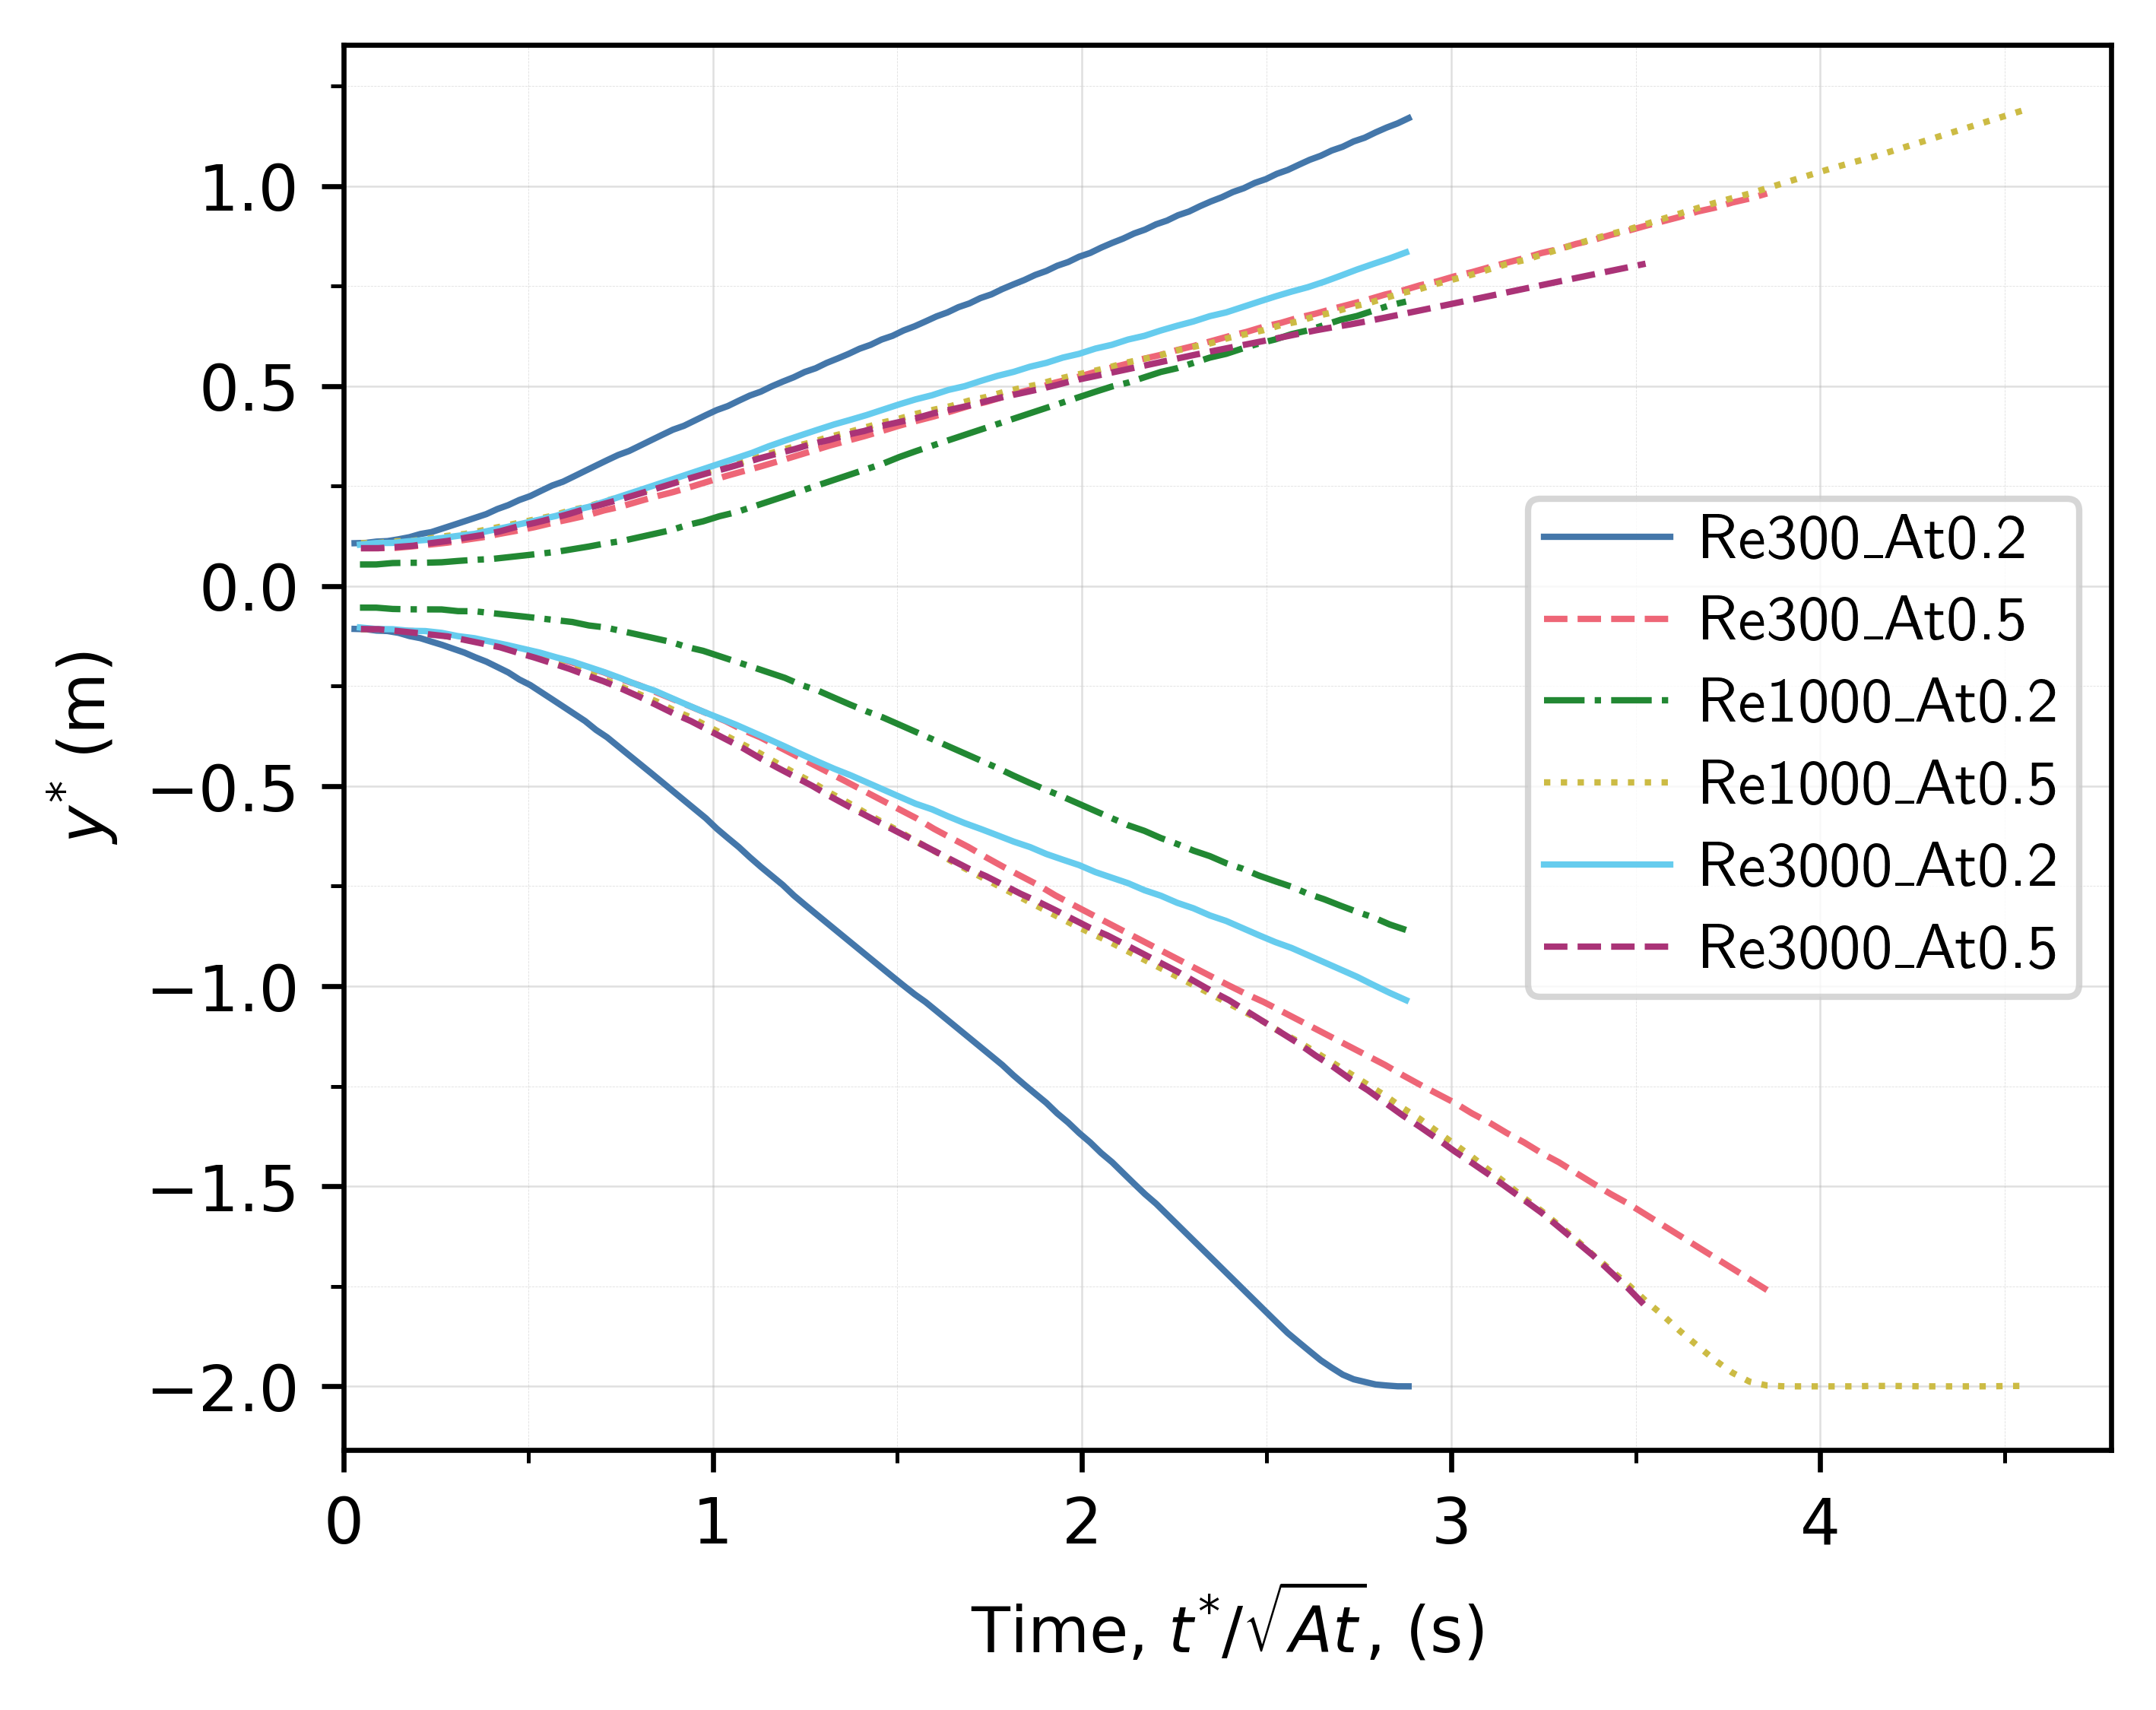

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from itertools import cycle
import scienceplots, tol_colors                       # nur für Styles

# ------------------------------------------------------------------
#  Pfade & Bezeichnungen
# ------------------------------------------------------------------
dir_list = [r"C:\Users\harsh\Desktop\pix\Re300_At0.2_sigma1e-05_dh0.0045",
            r"C:\Users\harsh\Desktop\pix\RT_evolution\re300_at05",
            r"C:\Users\harsh\Desktop\pix\Re1000_At0.2_sigma1e-05_dh0.0045",
            r"C:\Users\harsh\Desktop\pix\Re1000_At0.5_sigma1e-05_dh0.0045",
            r"C:\Users\harsh\Desktop\pix\RT_evolution\Re3000_At0.2_sigma1e-05_dh0.0045",
            r"C:\Users\harsh\Desktop\pix\RT_evolution\re3000_at05_0045"]

names    = ['Re300_At0.2', 'Re300_At0.5', 'Re1000_At0.2',
            'Re1000_At0.5', 'Re3000_At0.2', 'Re3000_At0.5']

name, name_append = 'isosurface_table_', '.csv'
Ats = [0.2, 0.5, 0.2, 0.5, 0.2, 0.5]


# ------------------------------------------------------------------
#  Daten einlesen
# ------------------------------------------------------------------
h_data = []
ref_t = lambda atwood_num: numpy.sqrt(atwood_num)
for idx, path in enumerate(dir_list):
    #ref_t = np.sqrt(Ats[idx])  # Referenzzeit für jedes Atwood-Zahl
    model.load_solution_data(path, name, name_append, name_vars, ref_t= ref_t)
    model.calculate_stuff()
    cur_h_data = {}
    cur_h_data['dh'] = names[idx]
    cur_h_data['nondimT'] = np.sqrt(Ats[idx])  # Referenzzeit für jedes Atwood-Zahl
    cur_h_data['timesteps'] = model.params['timesteps']
    cur_h_data.update(model.analysis_data)
    h_data.append(cur_h_data)

dns_df = pd.read_csv(
    r"C:\Users\harsh\Desktop\pix\RT_evolution\dns_compare_data\2D_Single-Mode_At0.5_Re300_A0.05.csv"
)

# ------------------------------------------------------------------
#  Plot
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 4), dpi=600)

with plt.style.context(['science-modern', 'high-contrast']):
    ls_cycle = cycle(['-', '--', '-.', ':'])        # vier verschiedene Stile

    for h in h_data:
        t_scale = h['timesteps']* h['nondimT']  # Zeit skalieren mit Atwood-Zahl
        # Bubble  (bekommt Legendeneintrag)
        line_bub, = ax.plot(t_scale,
                            h['y_bub'],
                            linestyle=next(ls_cycle),
                            label=h['dh'])

        # Spike   (gleiche Farbe & Linienstil, aber _kein_ Legendeneintrag)
        ax.plot(t_scale,
                h['y_spike'],
                color=line_bub.get_color(),
                linestyle=line_bub.get_linestyle(),
                label='_nolegend_')

    # --------------------------------------------------------------
    # Achsenformatierung
    # --------------------------------------------------------------
    ax.set_xlim(0)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))

    ax.set_xlabel(r'Time, $t^{*}/\sqrt{At}$, (s)')
    ax.set_ylabel(r'$y^{*}$ (m)')

    ax.grid(which='major', ls='-',  lw=0.3, alpha=0.4)
    ax.grid(which='minor', ls='--', lw=0.1, alpha=0.4)

    # --------------------------------------------------------------
    # Legende    (max. 2 Spalten, damit sie kürzer wirkt)
    # --------------------------------------------------------------
    ax.legend(loc='best', frameon=True, prop={'size': 10})

#plt.tight_layout()
plt.show()

In [ ]:
model.calculate_stuff()

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(model.params['timesteps'], numpy.abs(model.analysis_data['v_spike_file']), label='v_spike_file')
plt.plot(model.params['timesteps'][:-1], model.analysis_data['v_spike'], label='v_spike')
plt.xlabel("t")
plt.ylabel("Value (val)")
plt.title("val vs t")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Plot y_max and y_min on the same graph
plt.figure(figsize=(8, 5))
plt.plot(model.params['timesteps'], model.analysis_data['y_bub'], label='y_bub', marker = ".")
plt.plot(model.params['timesteps'], model.analysis_data['y_spike'], label='y_spike', marker = ".")
#plt.plot(nondimtime, y_s, label='y_min', marker = '.')
plt.xlabel("t")
plt.ylabel("y_bub and y_max")
plt.title("y_spike and y_max vs t")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#1010, 1414, 1818, 2222, 2626, 3030